In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
DATA_PATH = r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\data\processed"

In [3]:
nav = pd.read_csv(
    rf"{DATA_PATH}\clean_nav_history.csv"
)

performance = pd.read_csv(
    rf"{DATA_PATH}\clean_scheme_performance.csv"
)

transactions = pd.read_csv(
    rf"{DATA_PATH}\clean_investor_transactions.csv"
)

holdings = pd.read_csv(
    rf"{DATA_PATH}\09_portfolio_holdings_clean.csv"
)

fund_master = pd.read_csv(
    rf"{DATA_PATH}\01_fund_master_clean.csv"
)

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [5]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [6]:
risk_report = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    var95 = np.percentile(
        temp,
        5
    )

    cvar95 = temp[
        temp <= var95
    ].mean()

    risk_report.append([
        fund,
        var95,
        cvar95
    ])

risk_report = pd.DataFrame(
    risk_report,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

risk_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [7]:
risk_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
risk_report.to_csv(
    rf"{DATA_PATH}\var_cvar_report.csv",
    index=False
)

risk_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [9]:
top5 = (
    performance
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)["amfi_code"]
)

top5

14    120507
23    120844
30    101208
9     100025
4     119120
Name: amfi_code, dtype: int64

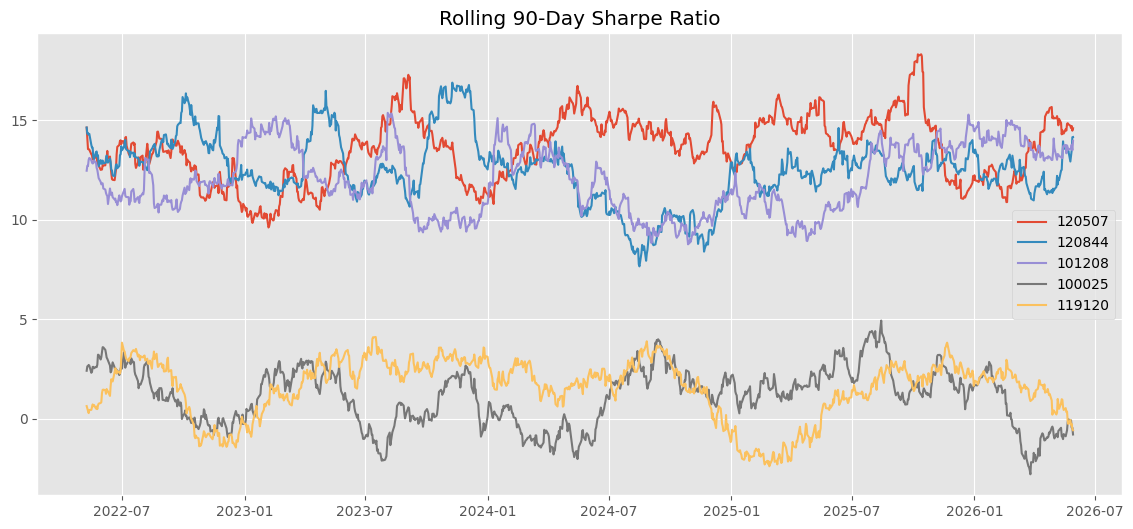

In [14]:
plt.figure(figsize=(14,6))

for fund in top5:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.legend()

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.savefig(
    r"C:\Users\CH V S PARDHU\bluestock_mf_capstone\reports\rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
first_txn = (
    transactions
    .groupby("investor_id")
    ["transaction_date"]
    .min()
)

transactions["cohort_year"] = (
    transactions["investor_id"]
    .map(first_txn)
    .dt.year
)

In [15]:
cohort_analysis = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_sip=("amount_inr","mean"),
        total_invested=("amount_inr","sum")
    )
)

cohort_analysis

,avg_sip,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [16]:
sip_txns = transactions[
    transactions["transaction_type"]
    == "SIP"
].copy()

In [17]:
sip_gap = []

for inv in sip_txns["investor_id"].unique():

    temp = sip_txns[
        sip_txns["investor_id"] == inv
    ]

    temp = temp.sort_values(
        "transaction_date"
    )

    if len(temp) >= 6:

        gap = (
            temp["transaction_date"]
            .diff()
            .dt.days
            .mean()
        )

        sip_gap.append([
            inv,
            gap,
            gap > 35
        ])

sip_gap = pd.DataFrame(
    sip_gap,
    columns=[
        "investor_id",
        "avg_gap_days",
        "at_risk"
    ]
)

sip_gap.head()

,investor_id,avg_gap_days,at_risk


In [21]:
print(sip_gap.shape)

(0, 3)


In [22]:
holdings["weight_sq"] = (
    holdings["weight_pct"] / 100
) ** 2

In [23]:
hhi = (
    holdings
    .groupby("amfi_code")
    ["weight_sq"]
    .sum()
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.sort_values(
    "HHI",
    ascending=False
).head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


In [24]:
hhi.to_csv(
    rf"{DATA_PATH}\hhi_report.csv",
    index=False
)

1. Fund 101207 exhibits one of the highest downside risk levels based on VaR and CVaR.

2. Top Sharpe Ratio funds maintain superior risk-adjusted performance over time.

3. Investor cohorts from 2024 contributed the majority of total investments.

4. SIP continuity analysis indicates a subset of investors may be at risk of discontinuing SIP contributions.

5. Funds with higher HHI values show greater sector concentration and lower diversification.